# Student C — Data Visualization

งานของ Student C คือ **เปลี่ยนผลวิเคราะห์และข้อมูลให้คนอ่านเข้าใจง่ายด้วยกราฟ**  
Notebook นี้ทำตามลำดับจากง่ายไปยาก และใช้ข้อมูลอุณหภูมิชุดเดียวกับงานของกลุ่ม

สิ่งที่เราจะทำ:
1. โหลดข้อมูล
2. เตรียมข้อมูลสำหรับกราฟ
3. Summary table
4. Boxplot เปรียบเทียบประเทศ
5. Histogram + fitted Normal distribution
6. Q-Q plot
7. Correlation heatmap
8. Interactive scatter / temperature trend
9. แสดงผล T-test และ ANOVA สำหรับใช้ใน Dashboard

> **หมายเหตุ:** วางไฟล์ CSV ไว้ในโฟลเดอร์เดียวกับ notebook นี้  
> ชื่อที่รองรับ: `GlobalLandTemperaturesByCountry_clean.csv` หรือ `GlobalLandTemperaturesByCountry.csv`  
> และ `GlobalTemperatures.csv`


## Cell 1 — Import libraries

`pandas` ใช้อ่านและจัดการตารางข้อมูล  
`numpy` ใช้คำนวณตัวเลข  
`matplotlib` ใช้วาดกราฟ  
`scipy.stats` ใช้ distribution, Q-Q plot และ statistical tests  
`plotly.express` ใช้สร้างกราฟ interactive


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


## Cell 2 — Load the datasets

โค้ดนี้พยายามหาไฟล์ cleaned ก่อน หากไม่มีจะใช้ไฟล์ raw แทน  
ดังนั้นท่านไม่ต้องแก้ชื่อไฟล์ทุกครั้ง


In [3]:
def find_file(candidates):
    search_folders = [Path("."), Path("./data")]
    for folder in search_folders:
        for name in candidates:
            path = folder / name
            if path.exists():
                return path
    raise FileNotFoundError(
        "Cannot find: " + ", ".join(candidates) +
        "\nPut the CSV file in the same folder as this notebook."
    )

country_path = find_file([
    "GlobalLandTemperaturesByCountry_clean.csv",
    "GlobalLandTemperaturesByCountry.csv"
])

country_df = pd.read_csv(country_path)

# Convert date column to datetime
country_df["dt"] = pd.to_datetime(country_df["dt"], errors="coerce")
country_df["Year"] = country_df["dt"].dt.year

print("Country dataset:", country_path)
print("Shape:", country_df.shape)
country_df.head()

Country dataset: GlobalLandTemperaturesByCountry.csv
Shape: (577462, 5)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year
0,1743-11-01,4.384,2.294,Åland,1743
1,1743-12-01,NaN,NaN,Åland,1743
2,1744-01-01,NaN,NaN,Åland,1744
3,1744-02-01,NaN,NaN,Åland,1744
4,1744-03-01,NaN,NaN,Åland,1744


## Cell 3 — Select countries used by Student B

Student B เปรียบเทียบ **Thailand, Japan และ Australia**  
Student C จึงใช้ประเทศเดียวกัน เพื่อให้กราฟกับผลสถิติเล่าเรื่องเดียวกัน


In [4]:
countries = ["Thailand", "Japan", "Australia"]

selected = country_df[
    country_df["Country"].isin(countries)
].dropna(subset=["AverageTemperature"]).copy()

selected[["dt", "Year", "Country", "AverageTemperature"]].head()

,dt,Year,Country,AverageTemperature
34816,1852-07-01,1852,Australia,14.116
34817,1852-08-01,1852,Australia,15.330
34818,1852-09-01,1852,Australia,18.740
34819,1852-10-01,1852,Australia,21.984
34820,1852-11-01,1852,Australia,24.073


## Cell 4 — Summary table

ตารางนี้ช่วยให้เห็นภาพรวมก่อนวาดกราฟ:
- `count` = จำนวนข้อมูล
- `mean` = อุณหภูมิเฉลี่ย
- `std` = การกระจาย
- `min`, `max` = ค่าต่ำสุดและสูงสุด


In [5]:
summary = (
    selected.groupby("Country")["AverageTemperature"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)

summary

,count,mean,std,min,median,max
Country,,,,,,
Australia,1930,21.62,4.89,12.53,22.13,29.86
Japan,2072,11.95,8.19,-2.26,12.76,26.64
Thailand,2246,25.99,2.01,20.10,26.58,30.44


## Cell 5 — Boxplot

**Boxplot** เหมาะสำหรับเปรียบเทียบ distribution ระหว่างประเทศ

อ่านง่าย ๆ:
- เส้นกลางกล่อง = median
- กล่อง = ช่วงกลางของข้อมูล
- จุดที่อยู่ไกลมาก = outliers

ถ้ากล่องของประเทศอยู่คนละระดับกันชัดเจน แปลว่าอุณหภูมิโดยรวมต่างกัน


C:\Users\Kanap\AppData\Local\Temp\ipykernel_11764\2493039721.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=countries, showfliers=True)


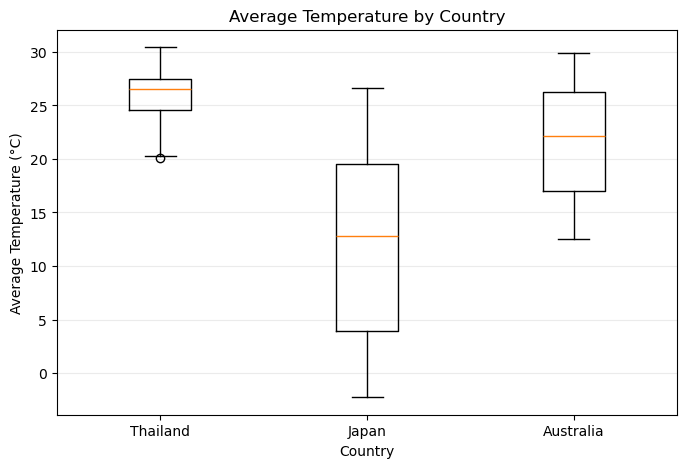

In [6]:
plot_data = [
    selected.loc[selected["Country"] == country, "AverageTemperature"]
    for country in countries
]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, labels=countries, showfliers=True)
plt.title("Average Temperature by Country")
plt.ylabel("Average Temperature (°C)")
plt.xlabel("Country")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Cell 6 — Histogram + fitted Normal distribution

Histogram แสดงว่าอุณหภูมิพบมากหรือน้อยแค่ไหนในแต่ละช่วง

เส้นโค้งคือ **Normal distribution ที่ fit จากข้อมูลจริง**  
ถ้าแท่ง histogram มีรูปทรงใกล้เส้นโค้ง แสดงว่าข้อมูลค่อนข้างใกล้ Normal distribution

ลองเปลี่ยน `country_to_plot` เป็น `"Japan"` หรือ `"Australia"` ได้


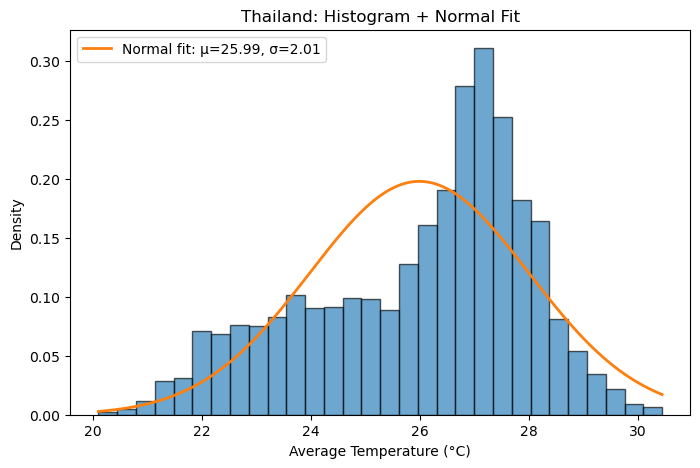

In [7]:
country_to_plot = "Thailand"

data = selected.loc[
    selected["Country"] == country_to_plot,
    "AverageTemperature"
].dropna().values

mu, sigma = stats.norm.fit(data)

x = np.linspace(data.min(), data.max(), 300)
pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, density=True, alpha=0.65, edgecolor="black")
plt.plot(x, pdf, linewidth=2, label=f"Normal fit: μ={mu:.2f}, σ={sigma:.2f}")
plt.title(f"{country_to_plot}: Histogram + Normal Fit")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Cell 7 — Q-Q Plot

Q-Q plot ใช้ตรวจว่าข้อมูลใกล้ **Normal distribution** หรือไม่

วิธีอ่าน:
- จุดเรียงใกล้เส้นตรง → ค่อนข้าง Normal
- จุดโค้งหรือหลุดจากเส้นมาก → ไม่ค่อย Normal

นี่เป็นภาพประกอบที่เข้าใจง่ายกว่าดู p-value อย่างเดียว


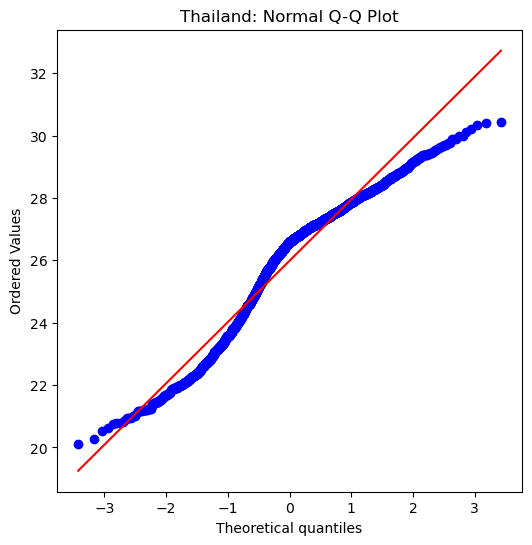

In [8]:
plt.figure(figsize=(6, 6))
stats.probplot(data, dist="norm", plot=plt)
plt.title(f"{country_to_plot}: Normal Q-Q Plot")
plt.show()

## Cell 8 — Correlation Heatmap

สำหรับ heatmap เราใช้ `GlobalTemperatures.csv` เพราะมีหลาย numeric variables  
เช่น Land Average, Land Max, Land Min และ Land/Ocean temperature

Correlation อยู่ระหว่าง **-1 ถึง +1**
- ใกล้ +1 = เพิ่มไปด้วยกัน
- ใกล้ -1 = ตัวหนึ่งเพิ่ม อีกตัวลด
- ใกล้ 0 = ความสัมพันธ์เชิงเส้นน้อย


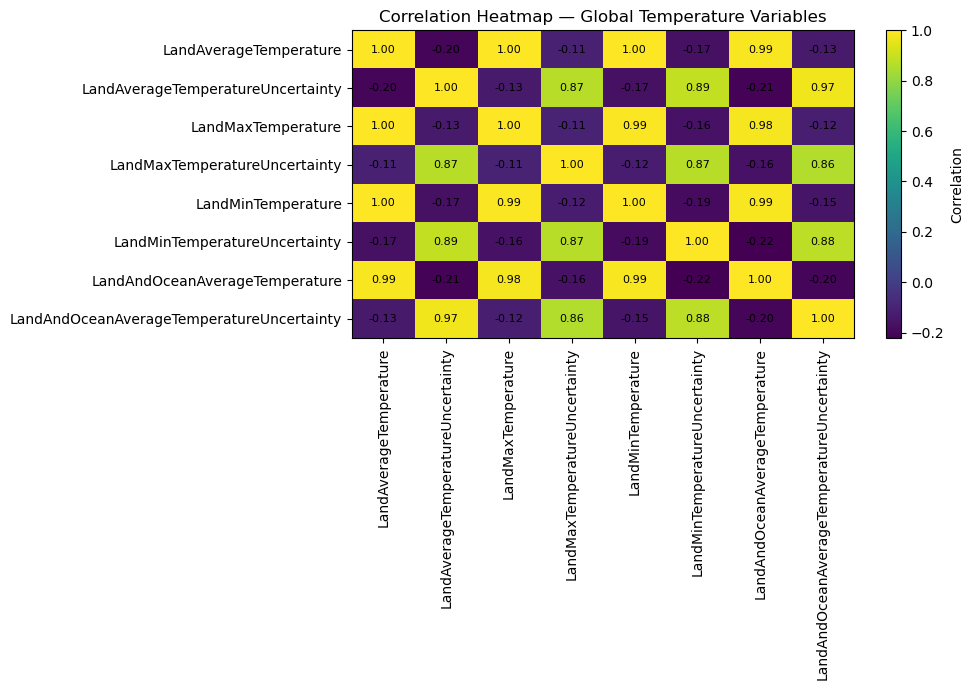

In [9]:
global_path = find_file(["GlobalTemperatures.csv"])
global_df = pd.read_csv(global_path)

numeric_cols = global_df.select_dtypes(include=np.number).columns.tolist()
corr = global_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr.values, aspect="auto")

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = corr.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Correlation")
plt.title("Correlation Heatmap — Global Temperature Variables")
plt.tight_layout()
plt.show()

## Cell 9 — Interactive Scatter / Temperature Trend

Plotly ทำให้กราฟ **zoom, hover และเปิด/ปิดประเทศ** ได้

กราฟนี้แสดง temperature record ตามเวลา โดยใช้สีแยกประเทศ


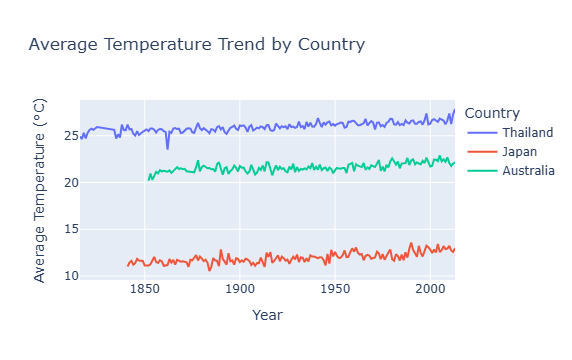

In [10]:
trend = (
    selected.dropna(subset=["Year"])
    .groupby(["Year", "Country"], as_index=False)["AverageTemperature"]
    .mean()
)

fig = px.line(
    trend,
    x="Year",
    y="AverageTemperature",
    color="Country",
    title="Average Temperature Trend by Country",
    labels={"AverageTemperature": "Average Temperature (°C)"}
)

fig.show()

## Cell 10 — Display Student B's hypothesis tests

Student C ไม่ได้แทนที่ Student B ในการทำ statistical analysis  
ส่วนนี้มีไว้ **แสดงผลใน visualization/dashboard** และตรวจให้กราฟสอดคล้องกับผลของ Student B

- 2 ประเทศ → Welch's independent t-test
- 3 ประเทศ → One-way ANOVA


In [11]:
thai = selected.loc[selected["Country"] == "Thailand", "AverageTemperature"].dropna()
japan = selected.loc[selected["Country"] == "Japan", "AverageTemperature"].dropna()
australia = selected.loc[selected["Country"] == "Australia", "AverageTemperature"].dropna()

# Welch's t-test
t_stat, t_p = stats.ttest_ind(thai, japan, equal_var=False)

# One-way ANOVA
f_stat, a_p = stats.f_oneway(thai, japan, australia)

print("Thailand vs Japan — Welch's t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {t_p:.6g}")
print("Conclusion:", "Significant difference" if t_p < 0.05 else "No significant difference")

print("\nThailand vs Japan vs Australia — One-way ANOVA")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {a_p:.6g}")
print("Conclusion:", "At least one country mean differs significantly" if a_p < 0.05 else "No significant difference detected")

Thailand vs Japan — Welch's t-test
T-statistic: 75.9233
P-value: 0
Conclusion: Significant difference

Thailand vs Japan vs Australia — One-way ANOVA
F-statistic: 3534.6896
P-value: 0
Conclusion: At least one country mean differs significantly
